# Compare deconvolution with and without copy number correction

Levels to think about:
- 10kb
- Per gene
- Per gene promoter

Ideas:
- Copy number correction may affect nucleosome occupancy and promoter occupancy during S-phase, thus we'll have to think about the low hanging fruit to show how copy number correction improves the fit of the chromatin deconvolution.
- At a high-level it should be most clear at the 10kb window.
- Then on the gene-level. The gene level is a bit more challenging because of the different regulation dynamics at play, but it allows us to investigate dosage compensation-type ideas.



In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from pipeline.copy_correction_analysis import CopyCorrectionAnalysis

copy_correction_analysis = CopyCorrectionAnalysis('output/prototype_pipeline_subset/')


In [3]:
copy_correction_analysis.load_chromosome(chrom=4)

In [5]:
copy_correction_analysis.load_replication_timing()

(0.0, 1530000.0)

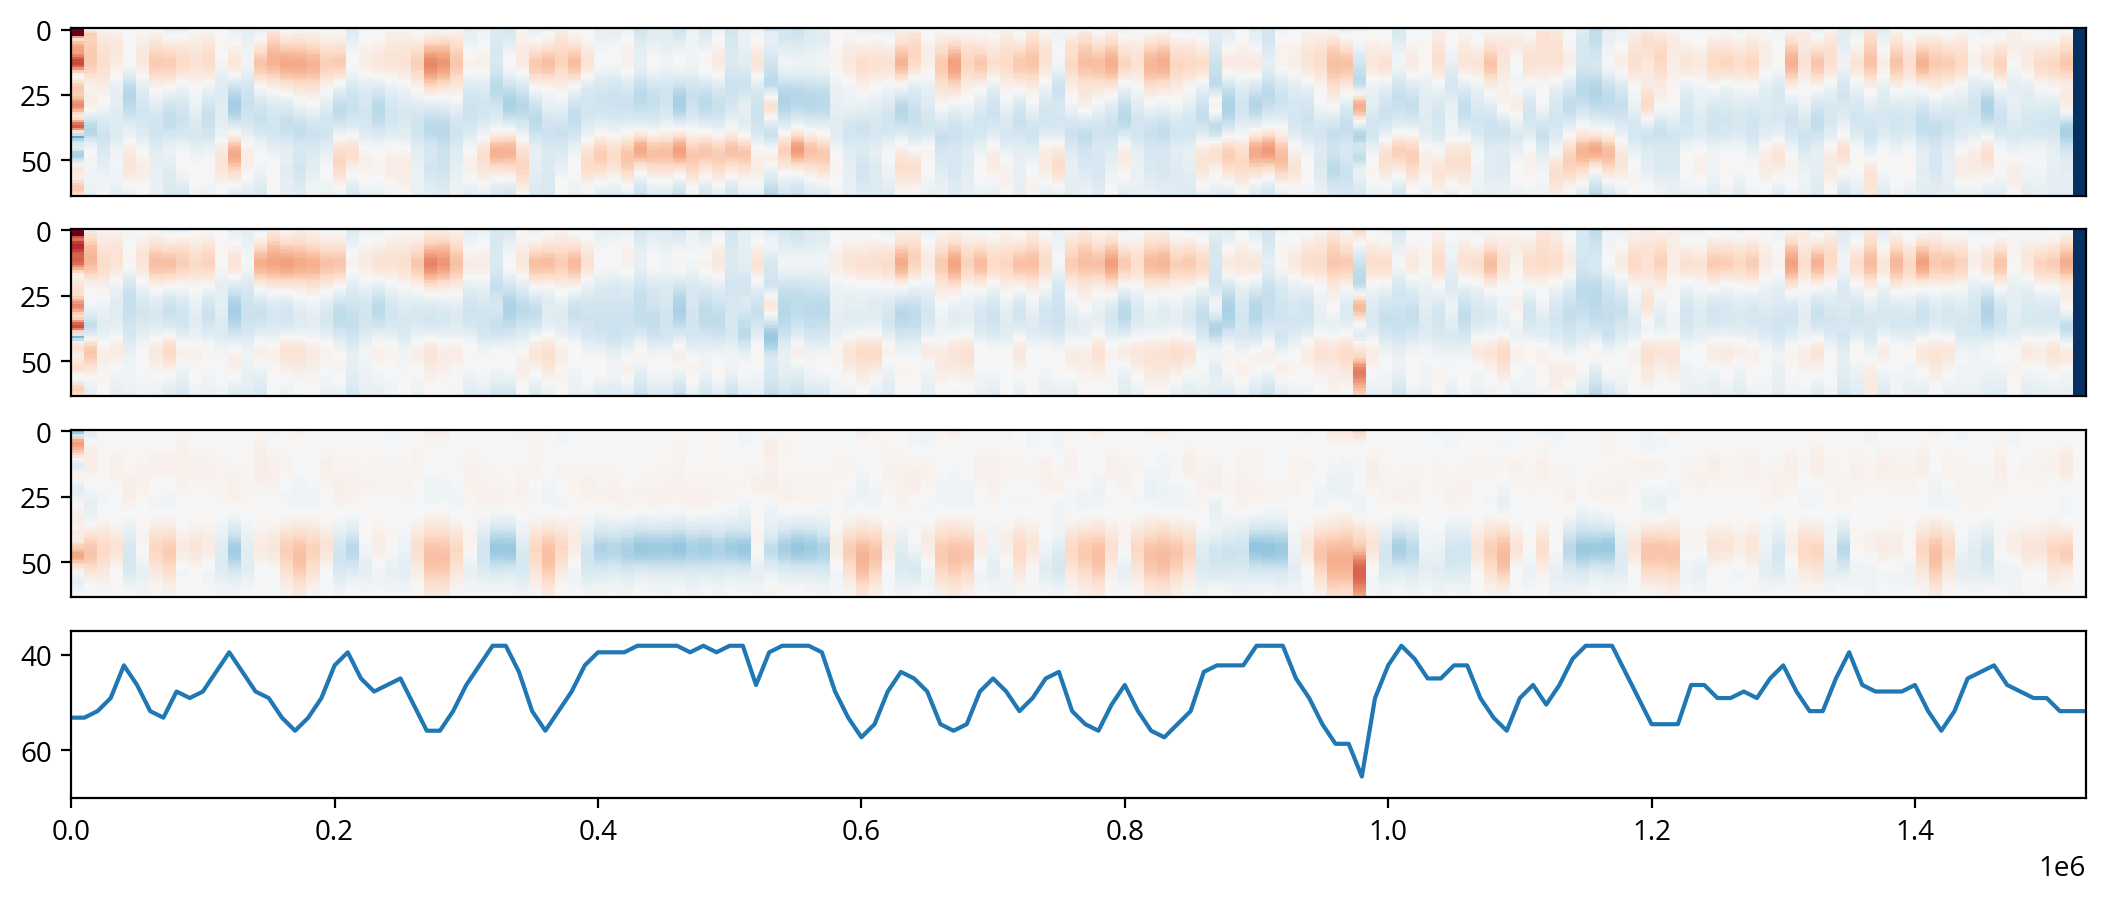

In [13]:
from src.config import load_default_expression_configs

config1, config2 = load_default_expression_configs()
    
fig = plt.figure(figsize=(13, 5))

nrows = 4

plt.subplot(nrows, 1, 1)
plt.imshow(copy_correction_analysis.chrom_no_cc_means.T[\
    config1.t_indices()], 
    vmin=0, vmax=2, cmap='RdBu_r', aspect='auto', interpolation='none')
plt.xticks([])

plt.subplot(nrows, 1, 2)
plt.imshow(copy_correction_analysis.chrom_b_copy_corrected_means.T[\
    config1.t_indices()], 
    vmin=0, vmax=2, cmap='RdBu_r', aspect='auto', interpolation='none')
plt.xticks([])

plt.subplot(nrows, 1, 3)
plt.imshow((copy_correction_analysis.chrom_b_copy_corrected_means-copy_correction_analysis.chrom_no_cc_means).T[\
    config1.t_indices()], 
    vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto', interpolation='none')
plt.xticks([])

plt.subplot(nrows, 1, 4)
plt.plot(copy_correction_analysis.chrom_replication_times.start,
         copy_correction_analysis.chrom_replication_times.replication_time)
plt.ylim(70, 35)
plt.xlim(0, copy_correction_analysis.chrom_windows.start.values[-1])


In [19]:
copy_correction_analysis.compute_ptrs()
# Compute PTRs

# PLot PTRs

# Plot example windows for early and late replicating



NameError: name 'no_cc_ptrs' is not defined

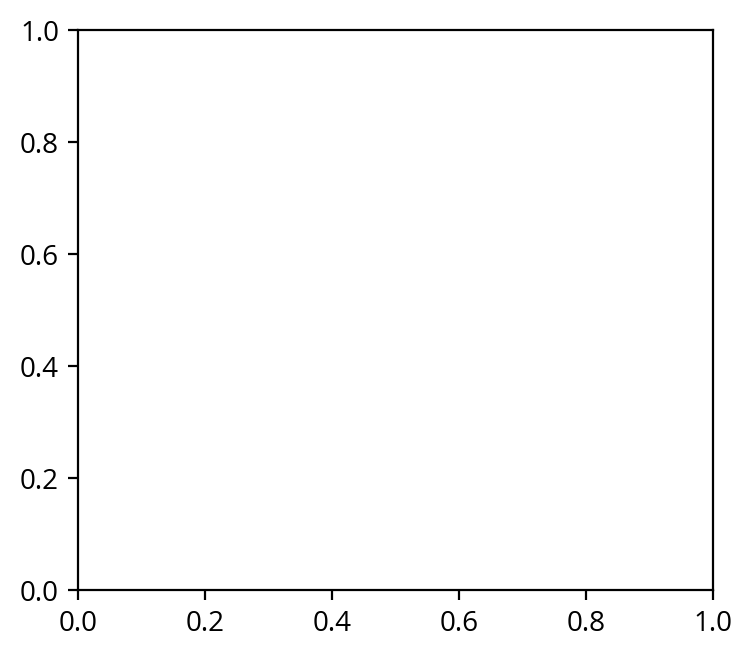

In [23]:
copy_correction_analysis.plot_branch_ptrs()